## **Лабораторная работа "Прогнозирование (метод сезонной декомпозиции)"**

**Задача:** Построить прогноз на 8 месяцев с применением метода сезонной декомпозиции.

**Общее описание данных:**

Гостиницы Чикаго.
В таблицах представлена статистика коэффициента загрузки гостиниц и средней цены по двум районам Чикаго: Chicago Central Business District Hotel Statistics и Chicago Metropolitan Area Hotel Statistics.
Данные собирались ежемесячно с января 1994 по апрель 2003.

**Вариант 2:** Средняя цена номера в отеле в долларах (Average Daily Rate (in $)). Данные для Chicago Central Business District Hotel Statistics. Предоставлены средние значения цены за один день. Усреднение по отелям и по дням месяца.

Данные расположены в столбце x2 файла Chicago_hotels.csv

In [22]:
# Импортируем необходимые для работы бибилиотеки
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# Загружаем данные
!gdown 1e86IS7-UQY2FXwvjDFBK5UH1989vJKcz

In [3]:
df = pd.read_csv('Chicago_hotels.csv', sep=';', decimal=',', na_values = " ")
df.head()

,date1,date2,x1,x2,x3,x4
0,January,1994,44.3,104.04,51.9,72.15
1,February,1994,54.7,102.74,60.1,73.47
2,March,1994,61.9,105.23,65.0,74.91
3,April,1994,69.1,113.63,69.8,79.06
4,May,1994,70.8,120.77,72.4,82.07


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date1   120 non-null    object 
 1   date2   120 non-null    int64  
 2   x1      112 non-null    float64
 3   x2      112 non-null    float64
 4   x3      112 non-null    float64
 5   x4      112 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 5.8+ KB


In [5]:
df.tail(10)

,date1,date2,x1,x2,x3,x4
110,March,2003,65.0,147.32,55.9,99.62
111,April,2003,69.0,150.72,58.4,101.32
112,May,2003,NaN,NaN,NaN,NaN
113,June,2003,NaN,NaN,NaN,NaN
114,July,2003,NaN,NaN,NaN,NaN
115,August,2003,NaN,NaN,NaN,NaN
116,September,2003,NaN,NaN,NaN,NaN
117,October,2003,NaN,NaN,NaN,NaN
118,November,2003,NaN,NaN,NaN,NaN
119,December,2003,NaN,NaN,NaN,NaN


Замечаем, что есть пропуски в данных, это месяцы, которые мы будем прогнозировать. Для построения модели будем использовать только наблюдаемую часть ряда без пропусков.

In [6]:
data = df.iloc[:112]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date1   112 non-null    object 
 1   date2   112 non-null    int64  
 2   x1      112 non-null    float64
 3   x2      112 non-null    float64
 4   x3      112 non-null    float64
 5   x4      112 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 5.4+ KB


Прогнозируем cреднюю цену номера в отеле в долларах (Average Daily Rate (in $)) - переменная x2

In [7]:
y = data['x2']

In [ ]:
# Установим даты
data['date'] = data['date1'] + ' ' + data['date2'].astype(str)
data['date'] = pd.to_datetime(data['date'])

data = data.set_index('date')

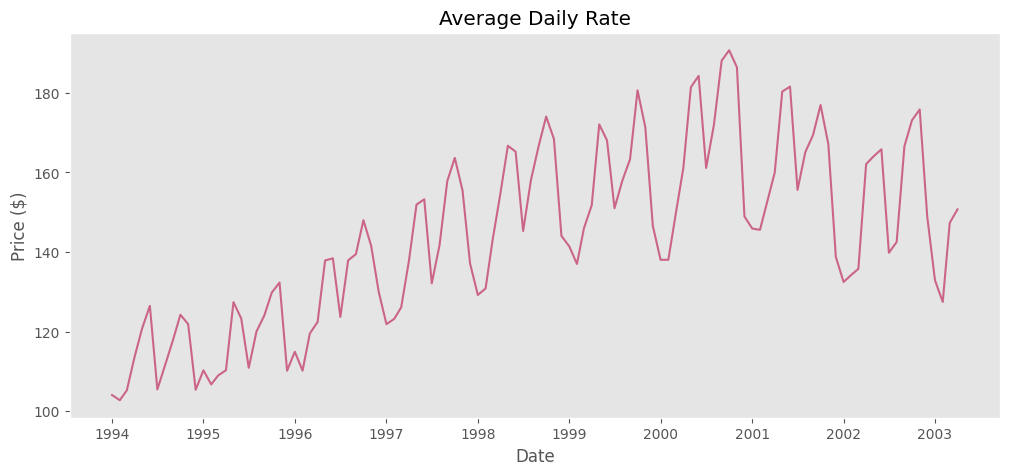

In [9]:
# Построим график временного ряда
y = data['x2']

plt.figure(figsize=(12,5))
plt.plot(y, color = '#CB6586')
plt.title('Average Daily Rate')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid()
plt.show()

По графику временного ряда наблюдается линейный тренд и годовая сезонность. Амплитуда сезонных колебаний увеличивается со временем, что указывает на мультипликативный характер сезонности.

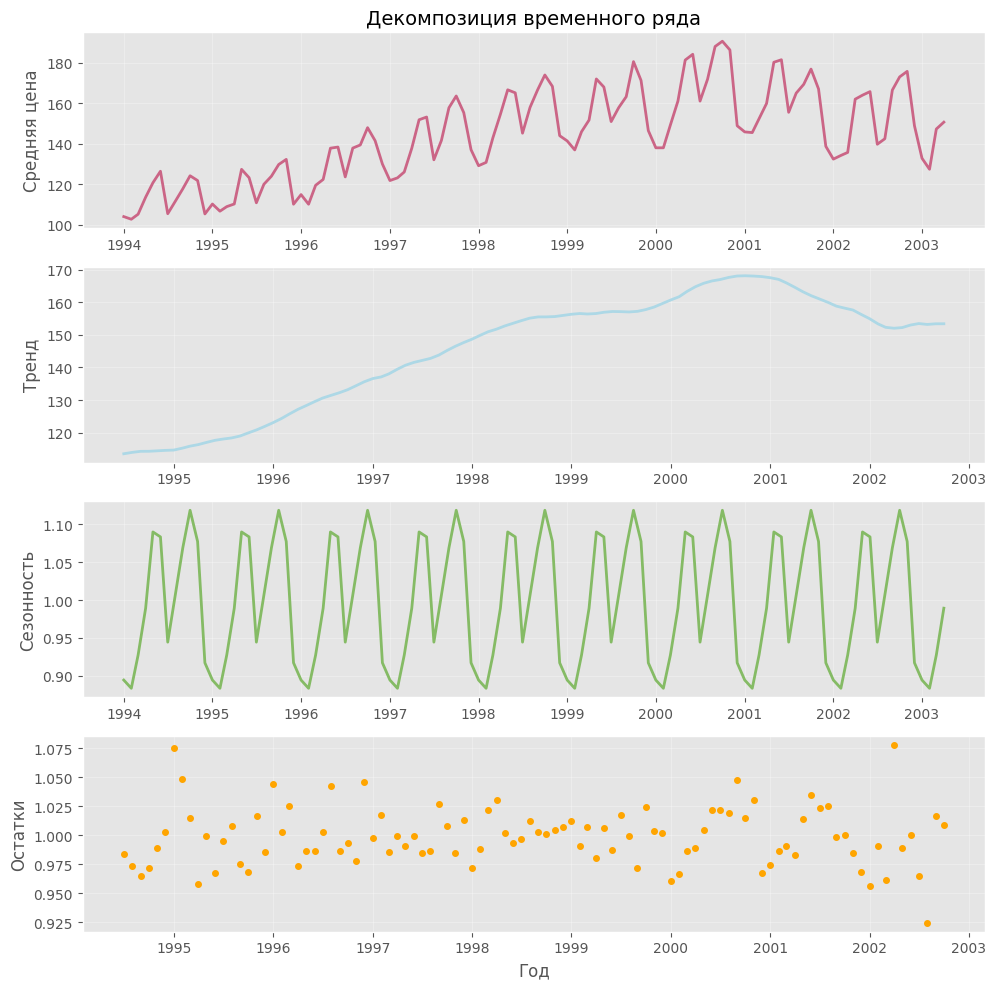

In [11]:
result = seasonal_decompose(y, model='multiplicative', period=12)
trend = result.trend
seasonal = result.seasonal
residual = result.resid

fig, axes = plt.subplots(4, 1, figsize=(10, 10))

# График наблюдений
axes[0].plot(result.observed.index, result.observed, color='#CB6586', linewidth=2)
axes[0].set_ylabel('Средняя цена')
axes[0].set_title('Декомпозиция временного ряда', fontsize=14)
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].grid(True, alpha=0.3)

# График тренда
axes[1].plot(trend.index, trend, color='lightblue', linewidth=2)
axes[1].set_ylabel('Тренд')
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].grid(True, alpha=0.3)

# График сезонности
axes[2].plot(seasonal.index, seasonal, color='#85BB65', linewidth=2)
axes[2].set_ylabel('Сезонность')
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].grid(True, alpha=0.3)

# График остатков
axes[3].plot(residual.index, residual, color='orange', marker='o', linestyle='none', markersize=4)
axes[3].set_ylabel('Остатки')
axes[3].set_xlabel('Год')
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# 1. Тренд
trend = result.trend.dropna()

# 2. Экстраполяция
trend_diff = np.diff(trend.values[-12:]).mean()
trend_forecast = [trend.values[-1] + trend_diff * i for i in range(1, 9)]

# 3. Сезонные коэффициенты для мая–декабря
season_forecast = result.seasonal.values[[4, 5, 6, 7, 8, 9, 10, 11]]

# 4. Итоговый прогноз (мультипликативная модель)
forecast = np.array(trend_forecast) * season_forecast

months = ['Май','Июнь','Июль','Август','Сентябрь','Октябрь','Ноябрь','Декабрь']
for m, v in zip(months, forecast):
    print(f"{m} 2003: ${v:.2f}")

Май 2003: $166.75
Июнь 2003: $165.33
Июль 2003: $143.78
Август 2003: $152.84
Сентябрь 2003: $161.90
Октябрь 2003: $168.98
Ноябрь 2003: $162.35
Декабрь 2003: $137.87


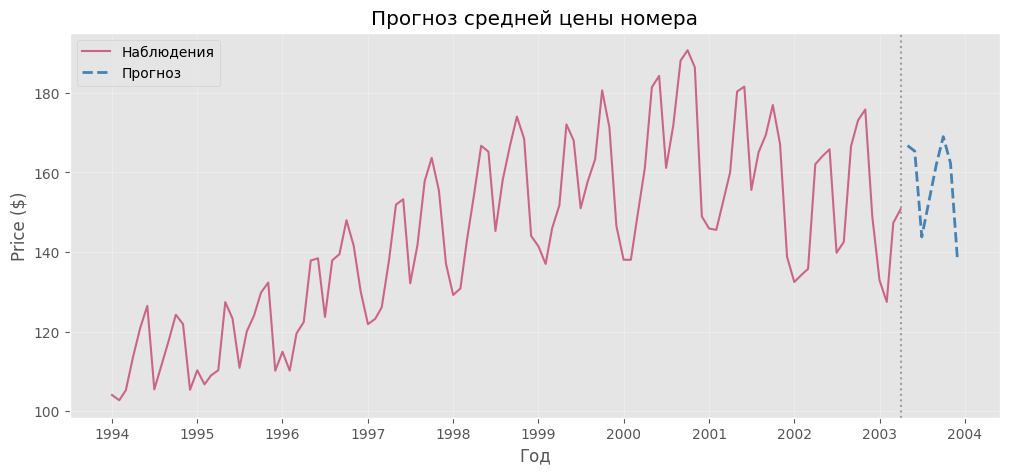

In [20]:
forecast_index = pd.date_range(start='2003-05-01', periods=8, freq='MS')

plt.figure(figsize=(12, 5))
plt.plot(y.index, y.values, color='#CB6586', label='Наблюдения')
plt.plot(forecast_index, forecast, color='steelblue', linewidth=2, linestyle='--', label='Прогноз')
plt.axvline(x=y.index[-1], color='gray', linestyle=':', alpha=0.7)
plt.title('Прогноз средней цены номера')
plt.xlabel('Год')
plt.ylabel('Price ($)')
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(alpha=0.3)
plt.show()

In [25]:
trend_full = result.trend.dropna()
seasonal_full = result.seasonal[result.trend.notna()]

fitted = trend_full.values * seasonal_full.values
actual = y[result.trend.notna()].values

# Метрики
mae = mean_absolute_error(actual, fitted)
rmse = np.sqrt(mean_squared_error(actual, fitted))
mape = np.mean(np.abs((actual - fitted) / actual)) * 100

print(f"MAE  (средняя абсолютная ошибка): ${mae:.2f}")
print(f"RMSE (среднеквадратичная ошибка): ${rmse:.2f}")
print(f"MAPE (средняя абсолютная ошибка в %): {mape:.2f}%")

MAE  (средняя абсолютная ошибка): $2.73
RMSE (среднеквадратичная ошибка): $3.54
MAPE (средняя абсолютная ошибка в %): 1.92%


**Вывод:** По результатам прогнозирования средней цены номера в отеле методом сезонной декомпозиции полученные значения находятся в диапазоне $137–169, что согласуется с наблюдаемой тенденцией.

Полученные метрики — MAE = 2.73 доллара, RMSE = 3.54 доллара, MAPE = 1.92% — свидетельствуют о высокой точности модели: средняя ошибка не превышает 2% от фактических значений.